# Initialization

In [2]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import importlib
import matplotlib.pyplot as plt
import numpy as np

import dynamics.Dynamics_spring_mass as Dynamics_spring_mass
import utils.control_chain as control_chain_module
import utils.mpc as mpc_module

importlib.reload(Dynamics_spring_mass)
importlib.reload(mpc_module)
importlib.reload(control_chain_module)

from utils.control_chain import (
    build_control_alphabet_from_saved_rollouts,
    evaluate_incremental_chain_policy,
    make_spring_mass_pd_backup,
    make_spring_mass_spec,
)
from utils.mpc import SpringMassParams, build_spring_mass_mpc, rollout_mpc


ERROR:2026-03-19 08:00:04,674:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/jixia/venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/jixia/venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/jixia/venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
/home/jixia/venv/lib/python3.12/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc

# Expert Data Synthesis

In [3]:
cfg = SpringMassParams(
    dt=0.02,
    n_horizon=120,
    x_ref=np.array([0.0, 0.0], dtype=float),
)
_, mpc, simulator = build_spring_mass_mpc(cfg)
sim_time = 10.0

spring_initial_states = {
    "x0_m2_0": np.array([-2.0, 0.0], dtype=float),
    "x1_m1_0": np.array([-1.0, 0.0], dtype=float),
    "x2_0_0": np.array([0.0, 0.0], dtype=float),
    "x3_1_0": np.array([1.0, 0.0], dtype=float),
    "x4_2_0": np.array([2.0, 0.0], dtype=float),
    "x5_0_2": np.array([0.0, 2.0], dtype=float),
    "x6_0_m2": np.array([0.0, -2.0], dtype=float),
    "x7_1p5_m1": np.array([1.5, -1.0], dtype=float),
}

all_rollouts = {}
for name, x0 in spring_initial_states.items():
    T, X, U = rollout_mpc(mpc, simulator, x0, sim_time=sim_time, save_U=False)
    all_rollouts[name] = (T, X, U)

save_dir = os.path.expanduser("~/exp/Nonparameric_Hamiltonian_Systems/data")
os.makedirs(save_dir, exist_ok=True)

for name, (T, X, U) in all_rollouts.items():
    np.save(os.path.join(save_dir, f"T_{name}.npy"), T)
    np.save(os.path.join(save_dir, f"X_{name}.npy"), X)
    np.save(os.path.join(save_dir, f"U_{name}.npy"), U)

np.savez(
    os.path.join(save_dir, "all_rollouts_spring_mass.npz"),
    target_state=cfg.x_ref,
    **{f"T_{k}": v[0] for k, v in all_rollouts.items()},
    **{f"X_{k}": v[1] for k, v in all_rollouts.items()},
    **{f"U_{k}": v[2] for k, v in all_rollouts.items()},
)

print("Saved spring-mass expert rollouts to:", save_dir)

Saved spring-mass expert rollouts to: /home/jixia/exp/Nonparameric_Hamiltonian_Systems/data


/tmp/ipykernel_1301/715488098.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


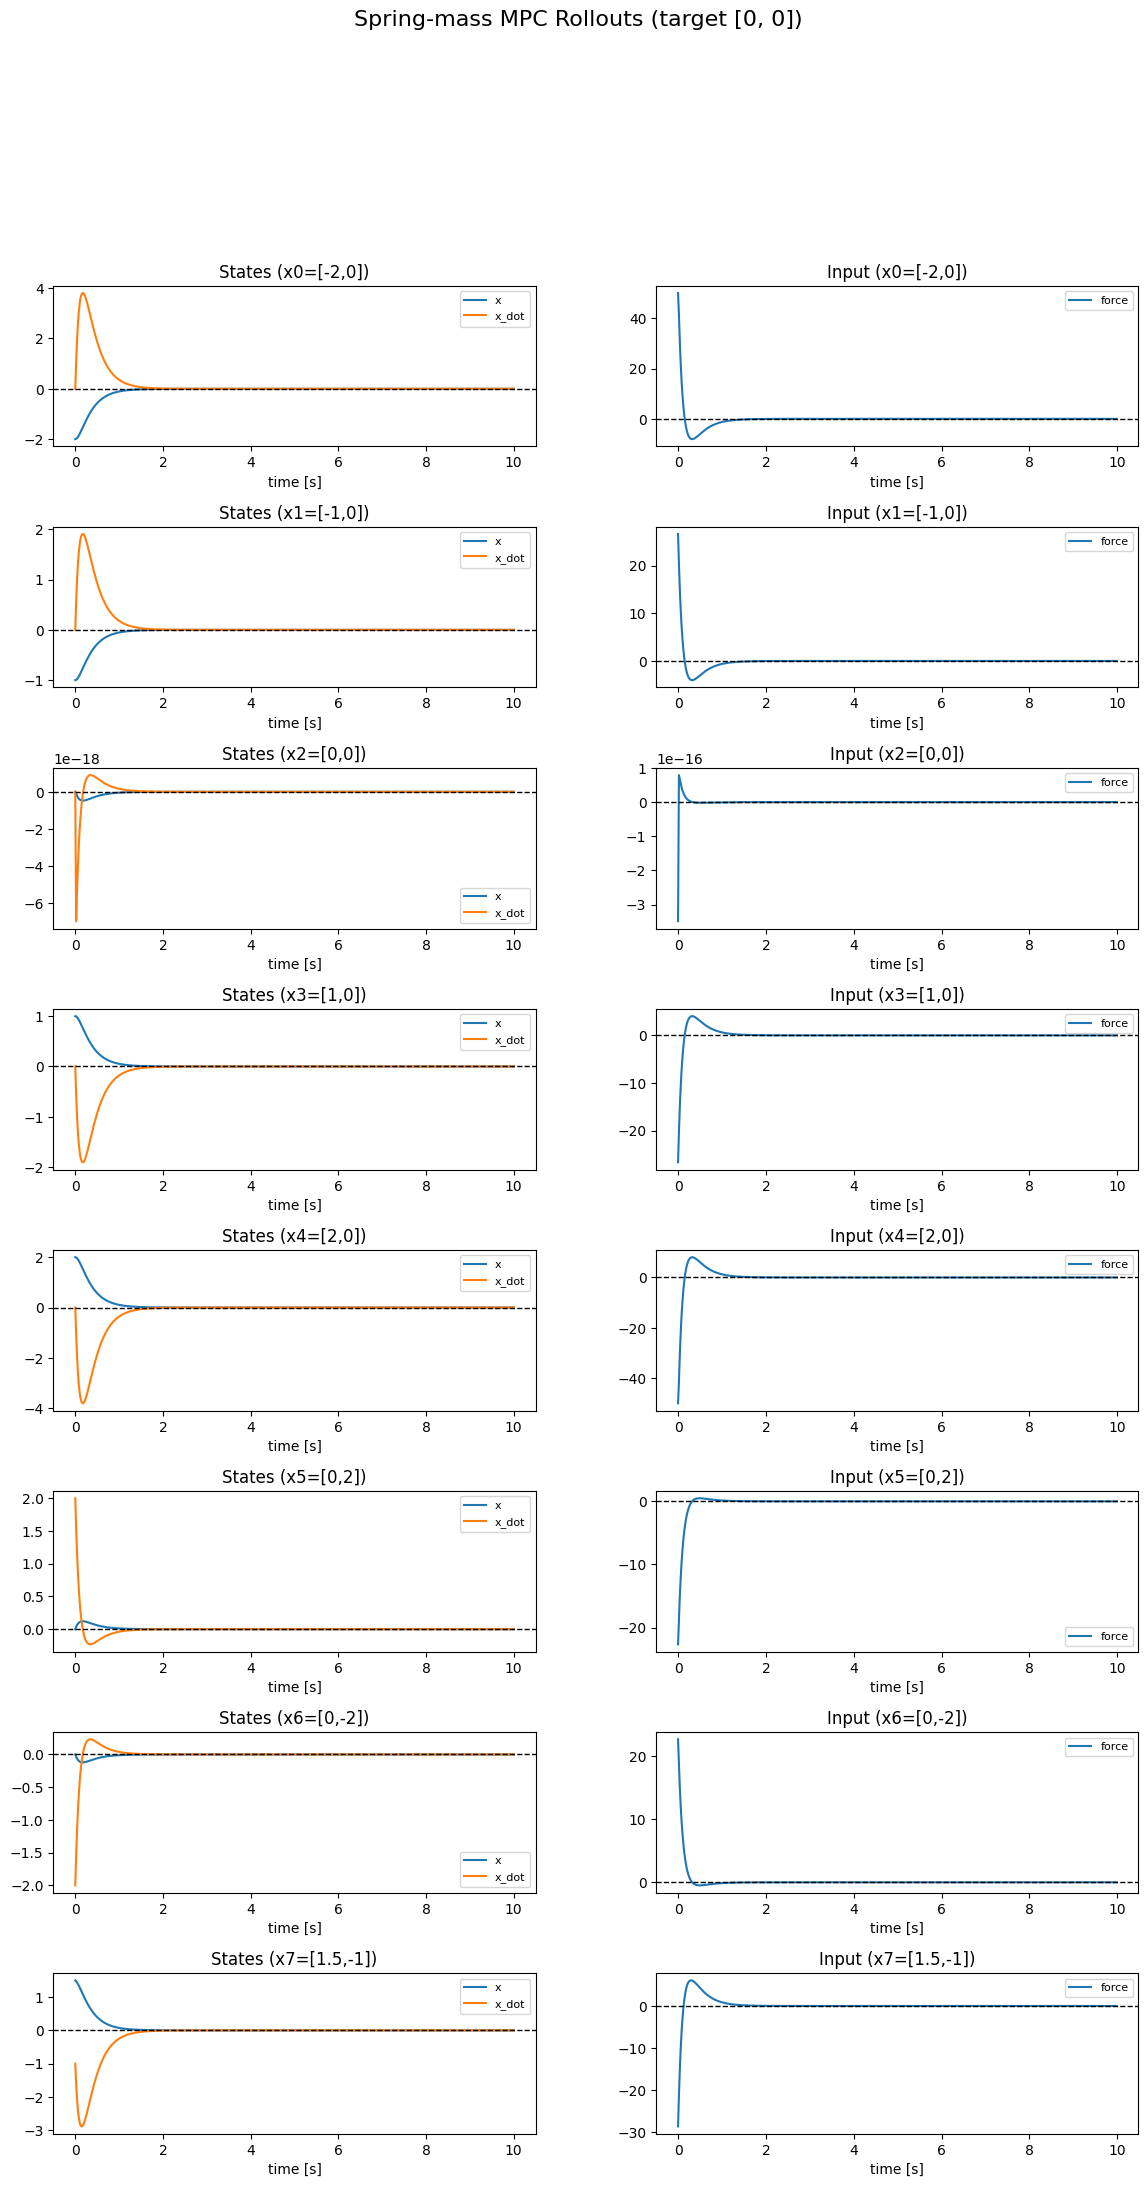

In [4]:
save_dir = os.path.expanduser("~/exp/Nonparameric_Hamiltonian_Systems/data")
npz_path = os.path.join(save_dir, "all_rollouts_spring_mass.npz")
data = np.load(npz_path, allow_pickle=True)

cases = [
    ("x0=[-2,0]", "x0_m2_0"),
    ("x1=[-1,0]", "x1_m1_0"),
    ("x2=[0,0]", "x2_0_0"),
    ("x3=[1,0]", "x3_1_0"),
    ("x4=[2,0]", "x4_2_0"),
    ("x5=[0,2]", "x5_0_2"),
    ("x6=[0,-2]", "x6_0_m2"),
    ("x7=[1.5,-1]", "x7_1p5_m1"),
]

fig = plt.figure(figsize=(14, 3 * len(cases)))
gs = fig.add_gridspec(len(cases), 2, hspace=0.5, wspace=0.25)

for row, (label, key) in enumerate(cases):
    T = data[f"T_{key}"]
    X = data[f"X_{key}"]
    U = data[f"U_{key}"]

    ax_state = fig.add_subplot(gs[row, 0])
    ax_state.plot(T, X[:, 0], label="x")
    ax_state.plot(T, X[:, 1], label="x_dot")
    ax_state.axhline(0.0, ls="--", lw=1, color="k")
    ax_state.set_title(f"States ({label})")
    ax_state.set_xlabel("time [s]")
    ax_state.legend(loc="best", fontsize=8)

    ax_u = fig.add_subplot(gs[row, 1])
    t_u = T[:-1] if U.shape[0] == T.shape[0] - 1 else T[: U.shape[0]]
    ax_u.plot(t_u, U[:, 0], label="force")
    ax_u.axhline(0.0, ls="--", lw=1, color="k")
    ax_u.set_title(f"Input ({label})")
    ax_u.set_xlabel("time [s]")
    ax_u.legend(loc="best", fontsize=8)

fig.suptitle("Spring-mass MPC Rollouts (target [0, 0])", y=0.995, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


# Chain Policy

In [ ]:
save_dir = os.path.expanduser("~/exp/Nonparameric_Hamiltonian_Systems/data")
spec = make_spring_mass_spec()
spring_names = list(spring_initial_states.keys())

generation_cfg = {
    "rho": 0.99,
    "H_star": 0.0,
    "eta": 0.0,
    "r_min": 1e-6,
    "max_lookahead": 200,
    "eps_L": 1e-5,
}

baseline_cfg = {
    "execute_full_sequence": False,
    "outside_mode": "nearest_control",
    "radius_scale": 4.0,
    "enter_threshold": 1.0,
    "abort_threshold": 1.5,
    "distance_weights": (1.0, 0.5),
}

backup_reference_cfg = {
    "execute_full_sequence": False,
    "outside_mode": "backup",
    "backup_controller": make_spring_mass_pd_backup(kp=8.0, kd=4.0),
    "enter_threshold": 0.0,
    "radius_scale": 1.0,
    "distance_weights": (1.0, 0.5),
}

spring_eval_init_states = spec.sample_initial_states(num_inits=20, seed=123)

all_alphabets, alphabet_summary = build_control_alphabet_from_saved_rollouts(
    spec=spec,
    save_dir=save_dir,
    names=spring_names,
    verbose=False,
    save_metrics=True,
    **generation_cfg,
)

alphabet_summary


[{'name': 'x0_m2_0',
  'n_tubes': 10,
  'r_min': 6.597694918042775e-06,
  'r_mean': 0.029700683404456744,
  'r_median': 0.001958647568097046,
  'r_max': 0.12847396793037033},
 {'name': 'x1_m1_0',
  'n_tubes': 10,
  'r_min': 3.285975627246887e-06,
  'r_mean': 0.014819728448369646,
  'r_median': 0.0009752836937296081,
  'r_max': 0.06427467394050601},
 {'name': 'x2_0_0',
  'n_tubes': 0,
  'r_min': nan,
  'r_mean': nan,
  'r_median': nan,
  'r_max': nan},
 {'name': 'x3_1_0',
  'n_tubes': 10,
  'r_min': 3.285975627246868e-06,
  'r_mean': 0.014819728448369627,
  'r_median': 0.0009752836937296104,
  'r_max': 0.06427467394050602},
 {'name': 'x4_2_0',
  'n_tubes': 10,
  'r_min': 6.597694918137103e-06,
  'r_mean': 0.029700683404637197,
  'r_median': 0.001958647568125035,
  'r_max': 0.12847396792999102},
 {'name': 'x5_0_2',
  'n_tubes': 10,
  'r_min': 4.790644095920211e-06,
  'r_mean': 0.050060557161802965,
  'r_median': 0.001420917715075973,
  'r_max': 0.45769794706886113},
 {'name': 'x6_0_m2',


[TubeController] loaded 10 tubes.
[TubeController] effective radius stats: min/med/max = 2.639e-05/7.835e-03/5.139e-01


CasADi - 2026-03-19 08:06:45 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:692]


[TubeController] loaded 20 tubes.
[TubeController] effective radius stats: min/med/max = 1.314e-05/4.794e-03/5.139e-01
[TubeController] loaded 20 tubes.
[TubeController] effective radius stats: min/med/max = 1.314e-05/4.794e-03/5.139e-01
[TubeController] loaded 30 tubes.
[TubeController] effective radius stats: min/med/max = 1.314e-05/4.794e-03/5.139e-01
[TubeController] loaded 40 tubes.
[TubeController] effective radius stats: min/med/max = 1.314e-05/4.794e-03/5.139e-01
[TubeController] loaded 50 tubes.
[TubeController] effective radius stats: min/med/max = 1.314e-05/4.794e-03/1.831e+00
[TubeController] loaded 60 tubes.
[TubeController] effective radius stats: min/med/max = 1.314e-05/4.794e-03/1.831e+00
[TubeController] loaded 70 tubes.
[TubeController] effective radius stats: min/med/max = 1.314e-05/4.794e-03/1.831e+00
baseline n_traj_list = [1, 2, 3, 4, 5, 6, 7, 8]
baseline success_rates = [0.05, 0.05, 0.05, 0.05, 0.1, 0.15, 0.05, 0.05]


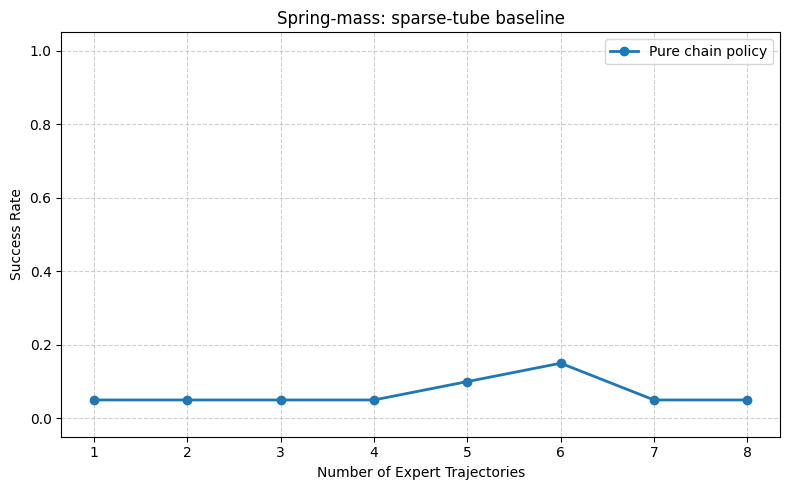

In [6]:
n_traj_baseline, success_rates_baseline, diag_baseline = evaluate_incremental_chain_policy(
    spec=spec,
    save_dir=save_dir,
    target_names=spring_names,
    init_states=spring_eval_init_states,
    dt=0.02,
    episode_seconds=20.0,
    controller_kwargs=baseline_cfg,
    result_filename="incremental_tube_success_rates_spring_mass.npz",
    plot=False,
    verbose=False,
)

print("baseline n_traj_list =", n_traj_baseline)
print("baseline success_rates =", success_rates_baseline)

plt.figure(figsize=(8, 5))
plt.plot(n_traj_baseline, success_rates_baseline, marker="o", linewidth=2, label="Pure chain policy")
plt.xlabel("Number of Expert Trajectories")
plt.ylabel("Success Rate")
plt.title("Spring-mass: sparse-tube baseline")
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


[TubeController] loaded 10 tubes.
[TubeController] effective radius stats: min/med/max = 6.598e-06/1.959e-03/1.285e-01
[TubeController] loaded 20 tubes.
[TubeController] effective radius stats: min/med/max = 3.286e-06/1.198e-03/1.285e-01
[TubeController] loaded 20 tubes.
[TubeController] effective radius stats: min/med/max = 3.286e-06/1.198e-03/1.285e-01
[TubeController] loaded 30 tubes.
[TubeController] effective radius stats: min/med/max = 3.286e-06/1.198e-03/1.285e-01
[TubeController] loaded 40 tubes.
[TubeController] effective radius stats: min/med/max = 3.286e-06/1.198e-03/1.285e-01
[TubeController] loaded 50 tubes.
[TubeController] effective radius stats: min/med/max = 3.286e-06/1.198e-03/4.577e-01
[TubeController] loaded 60 tubes.
[TubeController] effective radius stats: min/med/max = 3.286e-06/1.198e-03/4.577e-01
[TubeController] loaded 70 tubes.
[TubeController] effective radius stats: min/med/max = 3.286e-06/1.198e-03/4.577e-01
backup-reference n_traj_list = [1, 2, 3, 4, 5, 6

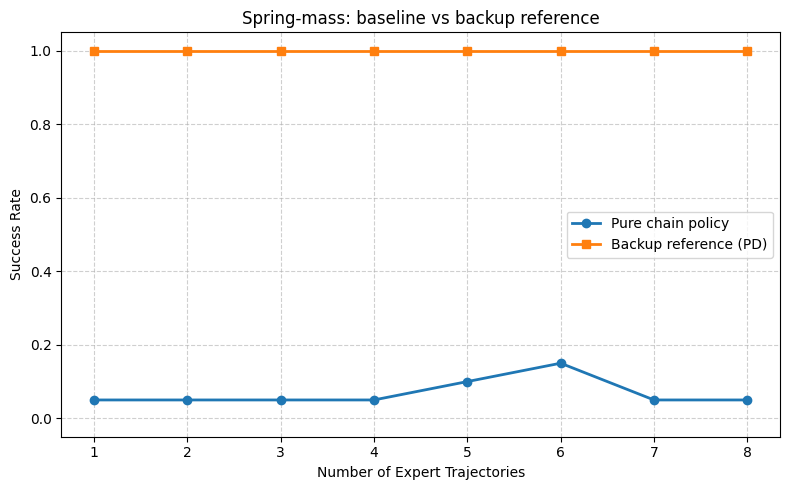

In [7]:
n_traj_backup, success_rates_backup, diag_backup = evaluate_incremental_chain_policy(
    spec=spec,
    save_dir=save_dir,
    target_names=spring_names,
    init_states=spring_eval_init_states,
    dt=0.02,
    episode_seconds=20.0,
    controller_kwargs=backup_reference_cfg,
    result_filename="incremental_tube_success_rates_spring_mass_backup_reference.npz",
    plot=False,
    verbose=False,
)

print("backup-reference n_traj_list =", n_traj_backup)
print("backup-reference success_rates =", success_rates_backup)

plt.figure(figsize=(8, 5))
plt.plot(n_traj_baseline, success_rates_baseline, marker="o", linewidth=2, label="Pure chain policy")
plt.plot(n_traj_backup, success_rates_backup, marker="s", linewidth=2, label="Backup reference (PD)")
plt.xlabel("Number of Expert Trajectories")
plt.ylabel("Success Rate")
plt.title("Spring-mass: baseline vs backup reference")
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
